# Baseline Replication — Karim et al. (2025)
Replicates Table 6 & 7 from the paper exactly:
- **Target:** `CCME_Values` (regression, 0–100)
- **Data:** Combined dataset (all 5 countries)
- **Preprocessing:** IQR outlier removal → MinMaxScaler → 80/20 split
- **Models:** Linear Regression, Decision Tree, Random Forest, XGBoost, ANN, LSTM

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

FEATURES = [
    "Ammonia (mg/l)",
    "Biochemical Oxygen Demand (mg/l)",
    "Dissolved Oxygen (mg/l)",
    "Orthophosphate (mg/l)",
    "pH (ph units)",
    "Temperature (cel)",
    "Nitrogen (mg/l)",
    "Nitrate (mg/l)",
]
TARGET = "CCME_Values"

In [2]:
# ── 1. Load combined dataset ─────────────────────────────────────────────────
df = pd.read_csv("data/Dataset/Combined Data/Combined_dataset.csv")
print(f"Raw shape: {df.shape}")
df = df[FEATURES + [TARGET]].dropna()
print(f"After dropna: {df.shape}")

Raw shape: (2827977, 14)
After dropna: (2827977, 9)


In [3]:
# ── 2. IQR outlier removal (paper: remove outliers before training) ───────────
def remove_iqr_outliers(df, cols):
    mask = pd.Series(True, index=df.index)
    for col in cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        mask &= df[col].between(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)
    return df[mask]

df = remove_iqr_outliers(df, FEATURES)
print(f"After IQR outlier removal: {df.shape}")

After IQR outlier removal: (1543979, 9)


In [4]:
# ── 3. MinMaxScaler + 80/20 split ────────────────────────────────────────────
X = df[FEATURES].values
y = df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]}  Test: {X_test.shape[0]}")

Train: 1235183  Test: 308796


In [5]:
# ── 4. Metrics helper ────────────────────────────────────────────────────────
def eval_model(name, y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{name:30s}  MSE={mse:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}")
    return {"Model": name, "MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2}

results = []

In [6]:
# ── 5. Classical ML models (all default params per paper) ────────────────────
for name, model in [
    ("Linear Regression",   LinearRegression()),
    ("Decision Tree",       DecisionTreeRegressor(random_state=SEED)),
    ("Random Forest",       RandomForestRegressor(random_state=SEED)),
    ("XGBoost",             XGBRegressor(random_state=SEED, verbosity=0)),
]:
    model.fit(X_train, y_train)
    results.append(eval_model(name, y_test, model.predict(X_test)))

Linear Regression               MSE=4.1087  RMSE=2.0270  MAE=1.6453  R2=0.9103
Decision Tree                   MSE=0.0001  RMSE=0.0097  MAE=0.0003  R2=1.0000
Random Forest                   MSE=0.0001  RMSE=0.0093  MAE=0.0002  R2=1.0000
XGBoost                         MSE=0.0231  RMSE=0.1521  MAE=0.0270  R2=0.9995


In [7]:
# ── 6. ANN — 1 hidden layer, 64 units, Adam, MSE, 30 epochs, batch 32 ────────
ann = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(len(FEATURES),)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1),
])
ann.compile(optimizer="adam", loss="mean_squared_error")
ann.fit(X_train, y_train, epochs=30, batch_size=32, verbose=0,
        validation_split=0.1)

results.append(eval_model("ANN", y_test, ann.predict(X_test).flatten()))

9650/9650 ━━━━━━━━━━━━━━━━━━━━ 3s 306us/step
ANN                             MSE=0.3379  RMSE=0.5813  MAE=0.2829  R2=0.9926


In [8]:
# ── 7. LSTM — 1 layer, 50 units, Adam, MSE, 30 epochs, batch 32 ──────────────
# Paper applies LSTM to tabular data -> reshape to (samples, 1, features)
X_train_lstm = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_lstm  = X_test.reshape(X_test.shape[0],  1, X_test.shape[1])

lstm = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1, len(FEATURES))),
    tf.keras.layers.LSTM(50),
    tf.keras.layers.Dense(1),
])
lstm.compile(optimizer="adam", loss="mean_squared_error")
lstm.fit(X_train_lstm, y_train, epochs=30, batch_size=32, verbose=0,
         validation_split=0.1)

results.append(eval_model("LSTM", y_test, lstm.predict(X_test_lstm).flatten()))

9650/9650 ━━━━━━━━━━━━━━━━━━━━ 4s 397us/step
LSTM                            MSE=0.3688  RMSE=0.6073  MAE=0.2586  R2=0.9919


In [9]:
# ── 8. Results table (compare with paper Table 7) ────────────────────────────
paper = pd.DataFrame([
    {"Model": "Linear Regression", "MSE": 2.63,   "RMSE": 1.62,  "MAE": 1.26,   "R2": 0.91},
    {"Model": "Decision Tree",     "MSE": 0.0001, "RMSE": 0.012, "MAE": 0.0002, "R2": 0.99},
    {"Model": "Random Forest",     "MSE": 0.0001, "RMSE": 0.012, "MAE": 0.0002, "R2": 0.99},
    {"Model": "XGBoost",           "MSE": 0.065,  "RMSE": 0.255, "MAE": 0.037,  "R2": 0.99},
    {"Model": "ANN",               "MSE": 0.352,  "RMSE": 0.593, "MAE": 0.347,  "R2": 0.99},
    {"Model": "LSTM",              "MSE": 0.040,  "RMSE": 0.200, "MAE": 0.027,  "R2": 0.99},
])

ours = pd.DataFrame(results)
ours[["MSE","RMSE","MAE","R2"]] = ours[["MSE","RMSE","MAE","R2"]].round(4)

print("\n=== Our results ===")
print(ours.to_string(index=False))
print("\n=== Paper Table 7 ===")
print(paper.to_string(index=False))

ours.to_csv("output/baseline_results.csv", index=False)


=== Our results ===
            Model    MSE   RMSE    MAE     R2
Linear Regression 4.1087 2.0270 1.6453 0.9103
    Decision Tree 0.0001 0.0097 0.0003 1.0000
    Random Forest 0.0001 0.0093 0.0002 1.0000
          XGBoost 0.0231 0.1521 0.0270 0.9995
              ANN 0.3379 0.5813 0.2829 0.9926
             LSTM 0.3688 0.6073 0.2586 0.9919

=== Paper Table 7 ===
            Model    MSE  RMSE    MAE   R2
Linear Regression 2.6300 1.620 1.2600 0.91
    Decision Tree 0.0001 0.012 0.0002 0.99
    Random Forest 0.0001 0.012 0.0002 0.99
          XGBoost 0.0650 0.255 0.0370 0.99
              ANN 0.3520 0.593 0.3470 0.99
             LSTM 0.0400 0.200 0.0270 0.99


9650/9650 ━━━━━━━━━━━━━━━━━━━━ 3s 332us/step
9650/9650 ━━━━━━━━━━━━━━━━━━━━ 4s 379us/step


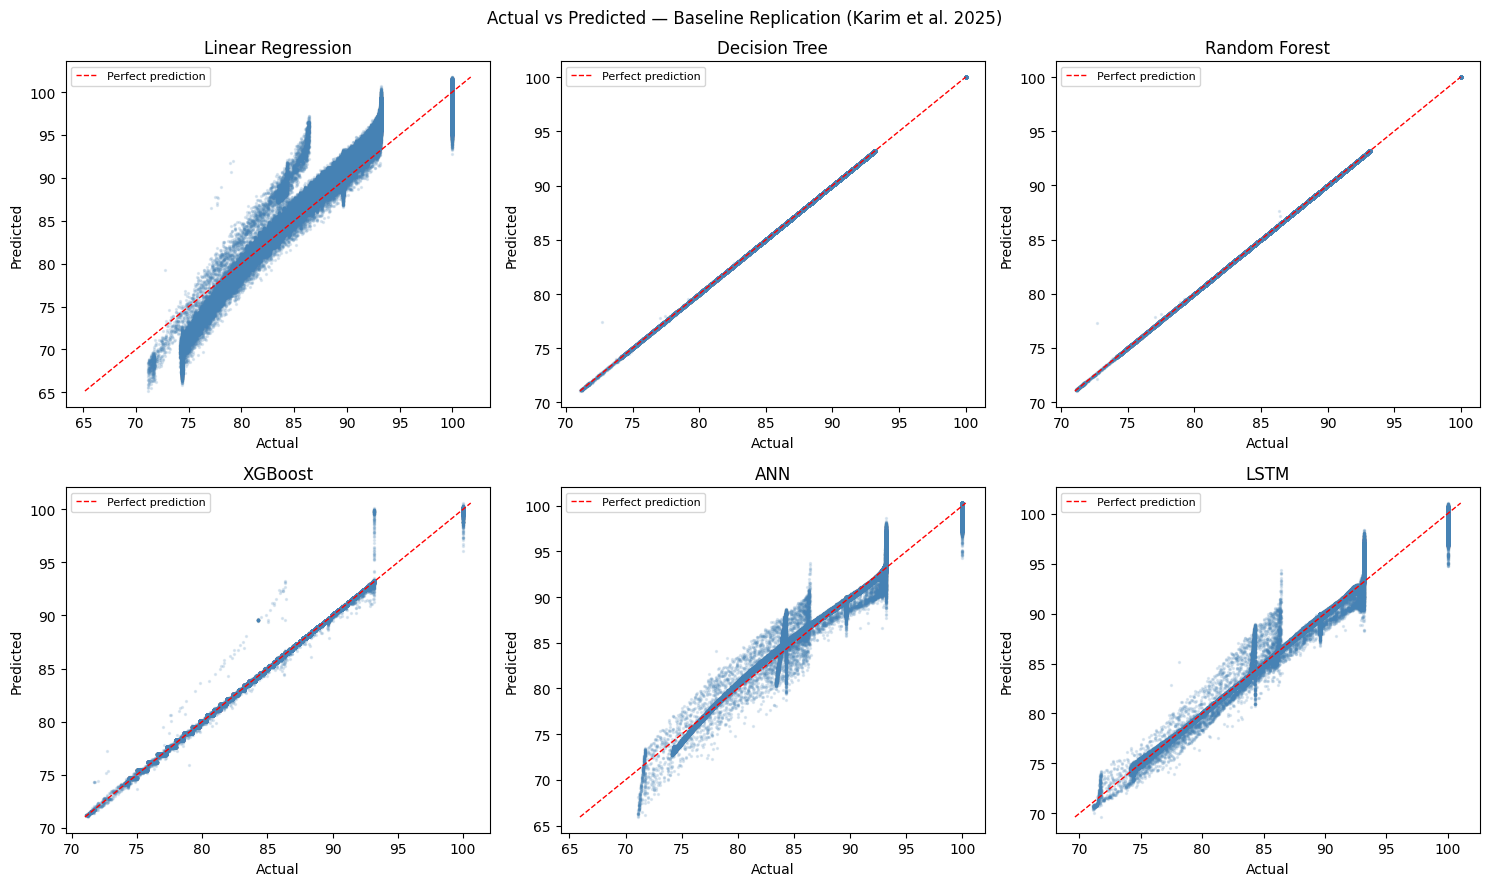

In [10]:
# ── 9. Actual vs Predicted plots (matches paper Fig. 5) ──────────────────────
models_trained = [
    ("Linear Regression",  LinearRegression().fit(X_train, y_train)),
    ("Decision Tree",      DecisionTreeRegressor(random_state=SEED).fit(X_train, y_train)),
    ("Random Forest",      RandomForestRegressor(random_state=SEED).fit(X_train, y_train)),
    ("XGBoost",            XGBRegressor(random_state=SEED, verbosity=0).fit(X_train, y_train)),
    ("ANN",                ann),
    ("LSTM",               lstm),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, (name, model) in zip(axes.flatten(), models_trained):
    if name == "LSTM":
        preds = model.predict(X_test_lstm).flatten()
    elif name == "ANN":
        preds = model.predict(X_test).flatten()
    else:
        preds = model.predict(X_test)

    ax.scatter(y_test, preds, alpha=0.15, s=2, color="steelblue")
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, "r--", lw=1, label="Perfect prediction")
    ax.set_xlabel("Actual"); ax.set_ylabel("Predicted")
    ax.set_title(name)
    ax.legend(fontsize=8)

plt.suptitle("Actual vs Predicted — Baseline Replication (Karim et al. 2025)")
plt.tight_layout()
plt.savefig("output/baseline_actual_vs_predicted.png", dpi=150)
plt.show()